<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

####  Análisis y Procesamiento de Señales - 1C 2026
# Trabajo Práctico Nº 2: Modelizando un ADC
#### Mariano Gonzalez


El ADC que deseamos simular trabajará a una frecuencia de muestreo fS=1000Hz y tendrá un rango analógico de ±VF=2 Volts. Esto nos indica que la señal de entrada deberá tener un amplitud pico a pico de 1v (desde -1v hasta 1v) para usar eficientemente el ADC, en caso de usar una amplitud menor estaríamos desperdiciando niveles para cuantizar. En el caso contrario, donde la señal supere el pico a pico, nuestro ADC recorta la señal cuantizada ya que no es capaz de representar niveles más allá de su rango.

Se simulará el comportamiento del dispositivo al digitalizar una senoidal contaminada con un nivel predeterminado de ruido. Comenzaremos describiendo los parámetros a ajustar de la senoidal:


- Frecuencia $f0$=$fS/N$=$\Delta$$f$

- Energía normalizada

## Generador de Senoidal y variables globales

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft

#%%Generador de senoidal
def mi_funcion_sen( vmax, dc, f0, ph, N, fs):
    tt=np.arange(0,N,1)*(1/fs)
    xx=dc + vmax*np.sin(2*np.pi*f0*tt + ph)
    return tt,xx 

# %% variables globales

#fase= np.pi/2  #fase
fs= 1000 #frecuencia de muestreo
nn=fs #muestra
f0=int(fs/nn) #f0
df=f0 #resolucion espectral
ts=1/fs # periodo muestreo

## Parámetros de la secuencia de ruido y cuantizador

Será de carácter aditivo, es decir la señal que entra al ADC será $sr = s + n$

- Siendo $n$ la secuencia que simula la interferencia, y $s$ la senoidal descrita anteriormente. Por lo tanto la sumatoria la definimos como $sr$

- La potencia del ruido será $Pn = kn \cdot Pq$ siendo el factor $k$ una escala para la potencia del ruido de cuantización $Pq=q^2/12$.

- $n$ será incorrelado y Gaussiano.

- El paso de cuantización se define como $q=Vfs/2^b$. Entonces si aumentamos el número de bits decrece el paso de cuantización, logrando una mejor resolución en nuestro ADC


In [3]:
#%% cuantizador 
b=4 # b-bits
vfs=2 #volts full scale
qq=(vfs)/(2**b) # paso de cuantizacion
pq= (qq**2)/12 # potencia señal
kn=1 #secuencia
pn=kn*pq


In [4]:
#%%Generador de ruido
ruido=np.random.normal(0,np.sqrt(pn),nn) # mu=0, sigma=varianza del ruido de nn muestra

### a) Generar el siguiente resultado producto de la experimentación. B = 4 bits, kn=1
En primer lugar vemos un ciclo de las 3 senoidales superpuestas, luego, en el segundo gráfico hacemos un zoom para que se distinga mejor 

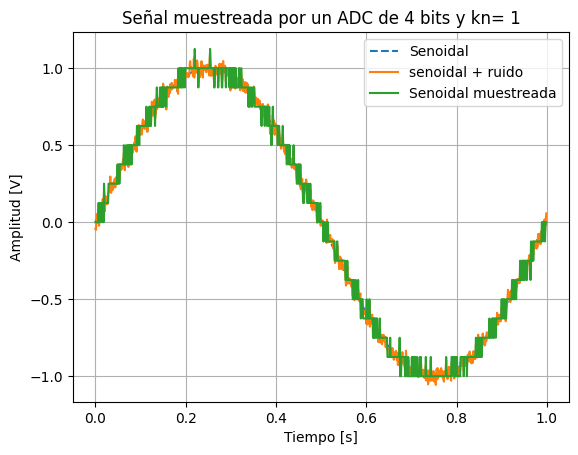

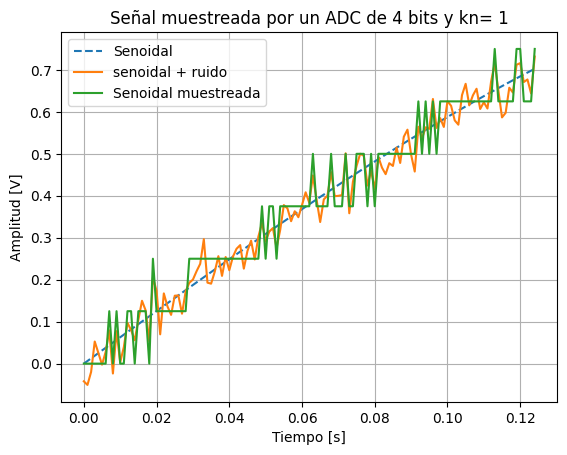

In [5]:
tt, xx = mi_funcion_sen( vmax = 1, dc = 0, f0 = f0, ph=0,N=nn, fs =fs)

sr = xx + ruido

xxq=np.round(sr/qq) *qq
un_ciclo=int(fs/f0) #para ver de un cliclo completo
plt.figure(1)
plt.clf()
plt.grid()
plt.plot(tt[:un_ciclo],xx[:un_ciclo],'--', label='Senoidal')
plt.plot(tt[:un_ciclo],sr[:un_ciclo], label='senoidal + ruido')
plt.plot(tt[:un_ciclo],xxq[:un_ciclo], label='Senoidal muestreada')
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')
plt.title(f"Señal muestreada por un ADC de {b} bits y kn= {kn}")
plt.legend()
plt.show()

un_ciclo=int((fs/f0)/8) #zoom para apreciar mejor el efecto 

plt.figure(2)
plt.clf()
plt.grid()
plt.plot(tt[:un_ciclo],xx[:un_ciclo],'--', label='Senoidal')
plt.plot(tt[:un_ciclo],sr[:un_ciclo], label='senoidal + ruido')
plt.plot(tt[:un_ciclo],xxq[:un_ciclo], label='Senoidal muestreada')
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')
plt.title(f"Señal muestreada por un ADC de {b} bits y kn= {kn}")
plt.legend()
plt.show()




#### Ahora necesitamos graficar la densidad espectral de potencia en dB en funcion de la frecuencia


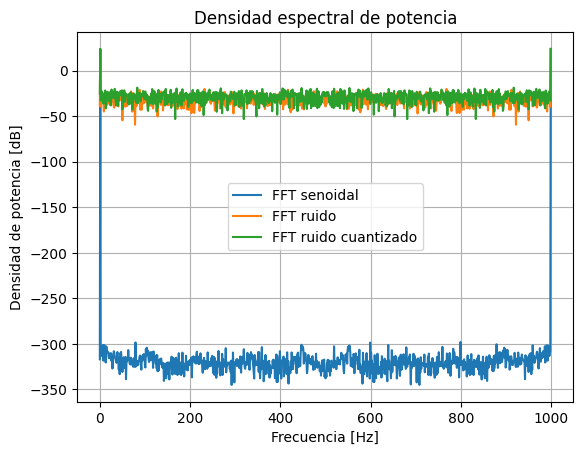

In [6]:
# %% FFTs
from numpy.fft import fft #lo tuve que importar de nuevo porque el notebook no me calculaba el XXQabs_2

# FFT de senoidal limpia
XX=fft(xx)
XXabs=np.abs(XX) 
XXabs_2=(XXabs**2)/nn# densidad espectral 

#FFT de senoidal + ruido
SR=fft(sr)
SRabs=np.abs(SR) 
SRabs_2=(SRabs**2)/nn  # densidad espectral

#FTT de senoidal + ruido cuantizada
XXQ=fft(xxq)
XXQabs=np.abs(XXQ) 
XXQabs_2=(XXQabs**2)/nn  # densidad espectral

FX= np.arange(nn)*df #defino el eje X en Hertz

plt.figure(3)
plt.clf()
plt.plot(FX,np.log10(XXabs_2)*10, label="FFT senoidal")
plt.plot(FX,np.log10(SRabs_2)*10, label="FFT ruido")
plt.plot(FX,np.log10(XXQabs_2)*10, label="FFT ruido cuantizado")
plt.plot()
plt.grid()
plt.title("Densidad espectral de potencia")
plt.ylabel('Densidad de potencia [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.legend()
plt.show()

#### Histograma de cuantización del error

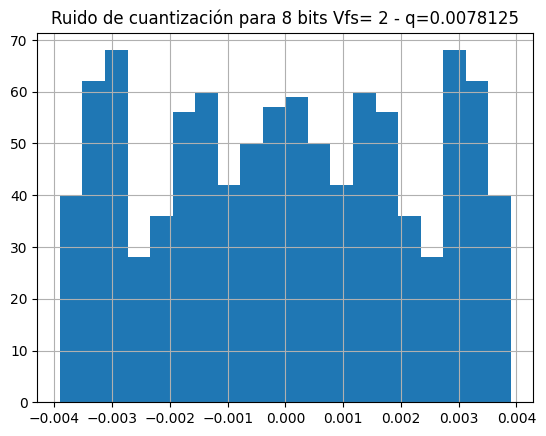

In [12]:
# %% ruido cuantizado

#secuencia de error
xxq=np.round(xx/qq) *qq #quedan en la misma magnitud que la senoidal
ee=xxq-xx #secueencia de error

plt.figure(4)
plt.clf()
plt.grid()
plt.hist(ee, bins=20)
plt.title(f"Ruido de cuantización para {b} bits Vfs= {vfs} - q={qq}")
plt.show()

### b) Analizar para una de las siguientes configuraciones B = ̣{4, 8 y 16} bits, kn={1/10,1,10}
Discutir los resultados respecto a lo obtenido en a). Debajo de cada grafico se discutira resultados

Seleccionamos B=8 y Kn=10

Para entender un poco estos valores: con 8 bits logramos una mayor resolución en el ADC, en este caso tenemos 256 niveles versus los 16 niveles con 4 bits. Kn=10 estamos aumentando x10 la potencia del ruido

In [7]:
#%% cuantizador 
b=8 # b-bits
vfs=2 #volts - full scale
qq=(vfs)/(2**b) # paso de cuantizacion
pq= (qq**2)/12 # potencia señal
kn=10 #secuencia
pn=kn*pq

In [8]:
#%%Generador de ruido
ruido=np.random.normal(0,np.sqrt(pn),nn) # mu=0, sigma=varianza del ruido de nn muestra

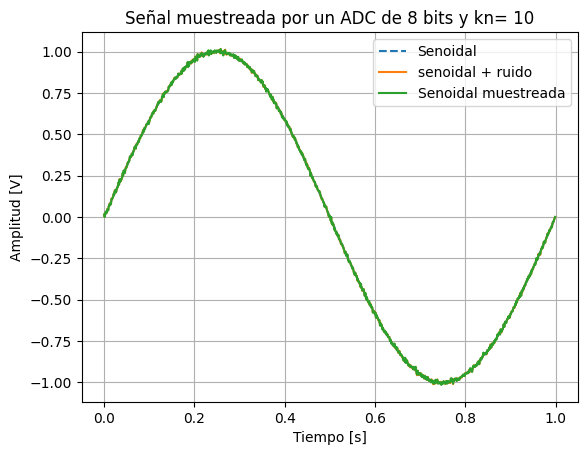

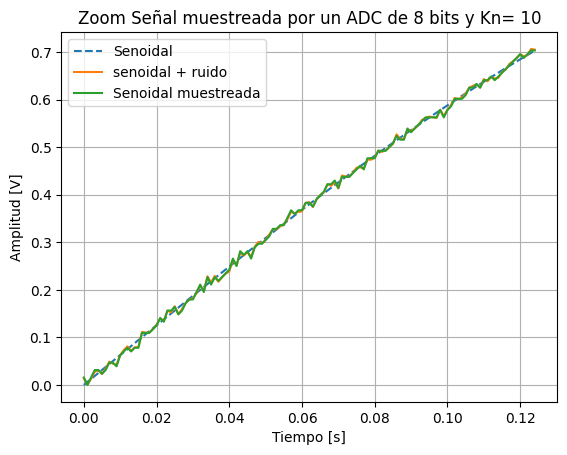

In [9]:
tt, xx = mi_funcion_sen( vmax = 1, dc = 0, f0 = f0, ph=0,N=nn, fs =fs)

sr = xx + ruido

xxq=np.round(sr/qq) *qq
un_ciclo=int(fs/f0) #para ver de un cliclo completo
plt.figure(1)
plt.clf()
plt.grid()
plt.plot(tt[:un_ciclo],xx[:un_ciclo],'--', label='Senoidal')
plt.plot(tt[:un_ciclo],sr[:un_ciclo], label='senoidal + ruido')
plt.plot(tt[:un_ciclo],xxq[:un_ciclo], label='Senoidal muestreada')
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')
plt.title(f"Señal muestreada por un ADC de {b} bits y kn= {kn}")
plt.legend()
plt.show()

un_ciclo=int((fs/f0)/8) #zoom para apreciar mejor el efecto 

plt.figure(2)
plt.clf()
plt.grid()
plt.plot(tt[:un_ciclo],xx[:un_ciclo],'--', label='Senoidal')
plt.plot(tt[:un_ciclo],sr[:un_ciclo], label='senoidal + ruido')
plt.plot(tt[:un_ciclo],xxq[:un_ciclo], label='Senoidal muestreada')
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')
plt.title(f"Zoom Señal muestreada por un ADC de {b} bits y Kn= {kn}")
plt.legend()
plt.show()

Discusión: se ve claramente que la senoidal cuantizada tiene un mejor aspecto que en el punto a), no es óptimo, pero es mejor. En el segundo gráfico con zoom aun se aprecia el ruido. Aumentando la escala de ruido a 10 veces respecto al ítem a) (Kn=10) estaríamos bajando la relación señal ruido (SNR) y aun así con el crecimiento de bits el resultado es mejor, se ve una senoidal cuantizada mejor representada.


#### Ahora necesitamos graficar la densidad espectral de potencia en dB en función de la frecuencia


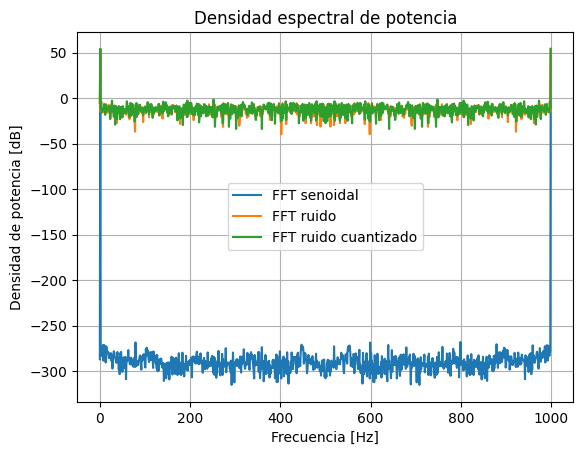

In [10]:
# %% FFTs

# FFT de senoidal limpia
XX=fft(xx)
XXabs=np.abs(XX) 
XXabs_2=(XXabs**2)/nn # densidad espectral 

#FFT de senoidal + ruido
SR=fft(sr)
SRabs=np.abs(SR) 
SRabs_2=(SRabs**2)/nn  # densidad espectral

#FTT de senoidal + ruido cuantizada
XXQ=fft(xxq)
XXQabs=np.abs(XXQ) 
XXQabs_2=(XXQabs**2)/nn  # densidad espectral

FX= np.arange(nn)*df #defino el eje X en Hertz

plt.figure(3)
plt.clf()
plt.plot(FX,np.log10(XXabs_2)*10, label="FFT senoidal")
plt.plot(FX,np.log10(SRabs_2)*10, label="FFT ruido")
plt.plot(FX,np.log10(XXQabs_2)*10, label="FFT ruido cuantizado")
plt.plot()
plt.grid()
plt.title("Densidad espectral de potencia")
plt.ylabel('Densidad de potencia [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.legend()
plt.show()

#### Histograma de cuantizacion del error

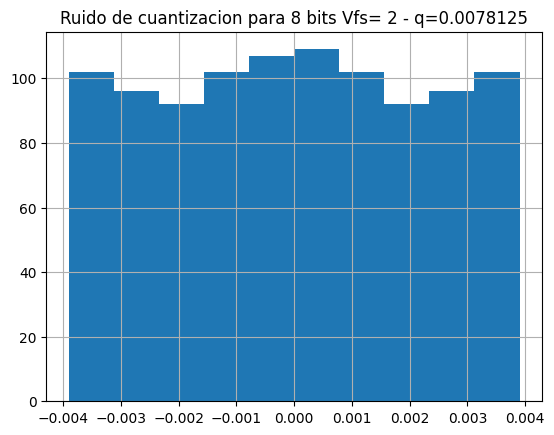

In [12]:
# %% ruido cuantizado

#secuencia de error
xxq=np.round(xx/qq) *qq #quedan en la misma magnitud que la senoidal
ee=xxq-xx #secueencia de error

plt.figure(4)
plt.clf()
plt.grid()
plt.hist(ee, bins=20)
plt.title(f"Ruido de cuantizacion para {b} bits Vfs= {vfs} - q={qq}")
plt.show()

Discusión: Como era de esperarse, al tener más niveles de cuantización con 8 bits, la distribución se ve más plana y uniforme que la de 8 bits

## Bonus
####  Encontrar la relación entre la cantidad de B bits del ADC y el SNR de la señal digitalizada



Un poco ya lo mencioné en la discusión de B), donde manifiesto que al aumentar la cantidad de bits mejoramos el SNR y por lo tanto la señal cuantizada se representa de mejor forma. Lo habíamos visto en clase cuando analizamos la ecuación de SNR, donde en el final de las cuentas observamos la dependencia directamente proporcional al número de bits. Además es importante resaltar que el cociente entre potencia de señal y el Vsf sean menor a 1, para que el primer término sea negativo, en la práctica es que la señal entre bien en el ratio de full scale de ADC, es decir que se aproveche bien los niveles (ENOB: número efectivo de bits).
Dejo fragmento de lo visto en clase


In [8]:
from IPython.display import IFrame

# Mostrar un PDF embebido en la notebook
IFrame("./TS2_SNRvsN-Bits.pdf", width=1000, height=1000)


#### Simular el efecto del aliasing junto con el muestreo.
Voy a forzar un F0 para que no cumpla Nyquist y que aparezca el efecto, usando la FFT veremos el pico donde no corresponde, esto es el efecto aliasing.
En el anterior punto nuestro F0=1Hz y veíamos el pico en 1Hz.

 ## Teorema de Nyquist

El **Teorema de Nyquist-Shannon** establece que:

> *Para poder reconstruir correctamente una señal analógica a partir de sus muestras digitales, la frecuencia de muestreo debe ser al menos el doble de la frecuencia máxima presente en la señal.*

\begin{equation}
f_s \geq 2 \cdot f_{\text{max}}
\end{equation}

> En el espectro digital aparece un pico en $f_{alias}=|f_0-kf_s|$

Seguimos con Fs=1000Hz, ahora con F0=600Hz, estamos por encima del umbral de Nyquist, el pico de frecuencia lo veremos en 400Hz y -400 Hz, lo cual es incorrecto ya que nuestra F0=600Hz. 


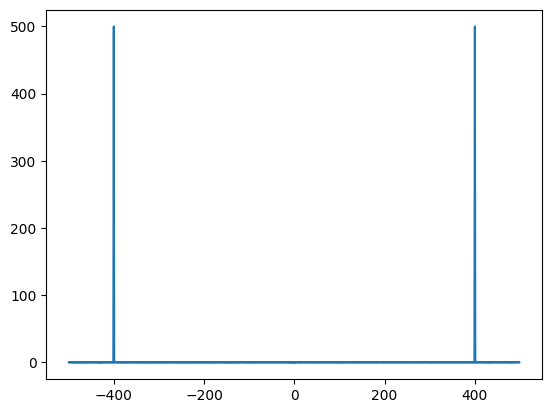

In [11]:
# %% efecto aliasing
fsb=1000
f0b=600
tsb=1/fsb

ttb, xxb = mi_funcion_sen( vmax = 1, dc = 0, f0 = f0b, ph=0,N=nn, fs =fsb)

srb = xxb + ruido

xxqb=np.round(srb/qq) *qq
FX2 = np.fft.fftfreq(nn, tsb)

XXQB=fft(xxqb)
XXQBabs=np.abs(XXQB) 
XXQBabs_2=(XXQBabs**2)/nn  # densidad espectral

plt.figure(6)
plt.clf()
plt.plot(FX2,XXQBabs)
plt.show()